# The matter-wave microscope

In this tutorial, we are going to demonstrate the working principles behind the [matter-wave microscope](https://www.nature.com/articles/s41586-021-04011-2), and see how it can be used to magnify the density profile of atomic Bose-Einstein condensates (BECs).

## Introduction

One of the challenges arising when studying BECs in optical lattices is the diffraction limit: Most optical lattices have very short lattice spacing, requiring extremely high numerical apertures to be properly imaged. These high apertures are usually not even sufficient in the case of arrays of cylindrical BECs, as the depth of view is limited. One method to overcome these limitations is the matter-wave microscope.

The matterwave microscope uses harmonic traps to realise transformation of the atomic wavefunctions equivalent to the effect of lenses on electromagnetic fields. This can be understood readily by noticing that a quarter-period evolution in a harmonic trap of angular frequency $\omega$ as the same effect on the wavefunction $\psi (t = 0)$ that of a Fourier transform.

Let's demonstrate this with some simple simulations. We are going to simulate the evolution of a gaussian wavepacket with various parameters and see what happens over a quarter-period in an harmonic trap.


C:\Users\marti\OneDrive\Documents\MyLibraries\bloch_schrodinger\bloch_schrodinger\plotting.py:946: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


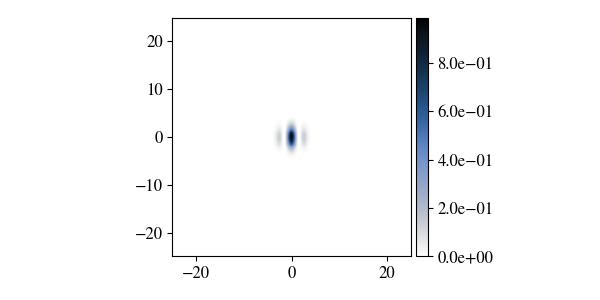

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.plotting import plot_eigenvector
from BECs.ssfm import SSFM
from BECs.potentialT import PotentialT
from BECs.ufuncs import gaussian2D



%matplotlib widget

### ----------------------
# Setting up the potential

s = 50 # simulation box size
resolution = (256,256) # Simulation box resolution

harmonic_trap = Potential( # For now, we only need a simple Potential object
    unitvecs=[[s, 0], [0, s]], # A square box of side s
    resolution=resolution,
    v0 = 0
)

T = 20 # Period, in arbitrary time unit
omega = 2 * np.pi / T # angular frequency of the trap

harmonic_trap.set( # We set the potential profile
    (harmonic_trap.x**2 + harmonic_trap.y**2) * omega**2 / 2
)

### ----------------------
# Setting up initial wavepacket, with a few parameter dimensions

k = create_parameter("k", np.linspace(1,3, 3)) # Initial wave-vector of the packet
sigma = create_parameter("sigma", np.linspace(2, 4, 2)) # Initial wavepacket width

psi0 = gaussian2D( # The initial wavepacket is a superposition of two gaussian wavepacket with a opposite wavevectors k and -k
    harmonic_trap.x, harmonic_trap.y,
    x0 = 0, y0 = 0,
    sigmax= sigma, sigmay=sigma,
    amp = 1
) * np.cos(harmonic_trap.x * k)

# We can use the plot_eigenvector function to plot the mode profile

plot_eigenvector(
    [[abs(psi0)**2]], [[None]], [['amplitude']]
)
plt.show()

Now we can simulate the time-evolution of this wavepacket. Using the Gross-Pitaevskii equation here, when there is no interactions is very much overkill, but in real systems, the interactions cannot always be suppressed.

In [38]:
g = 0 # Interactions
t_init = 0
t_final = T / 4 # We are going to simulate a quarter period evolution

t_samples = create_parameter('t', np.linspace(t_init, t_final, 50)) # We are going to save 50 time points

foo = SSFM(
    potential = harmonic_trap, psi0 = psi0, g = 0
)

psi = foo.solve(
    t_init, t_final, t_samples, parallelize=True, n_cores=6 # We are going to parallelize on 6 cores, if your machine does not support it, feel free to lower n_cores
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   10.4s remaining:   10.4s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   10.6s finished


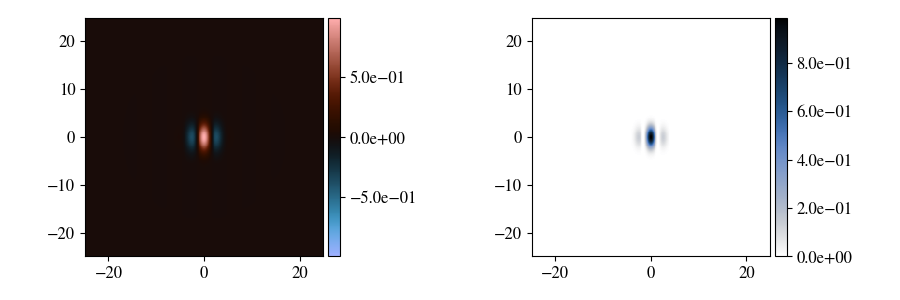

In [39]:
plot_eigenvector(
    [[psi.real, abs(psi)**2]], [[None]*2], [['real', 'amplitude']]
)
plt.show()

We can clearly see here that at the end of the quarter period, the wavepacket has been fully converted to its Fourier transform. Larger wavepackets in real space are more localized in k-space, in agreement with the Heisenberg principle, and higher k-components are further away from the origin.

It is also straightforward to understand that a stronger harmonic trap will lead to a smaller k-space, and vice-versa. From this, it follows easily that a stronger harmonic trap can be represented by a convergent lense of smaller focal length. Thus, if one chains two quarter-period evolutions in traps of frequencies $\omega_1$ and $\omega_2$, one can realise the equivalent of a 4f telescope with a magnification factor of $M = -\omega_1 / \omega_2$. Let's demonstrate this now, using the same initial state $\psi_0$.

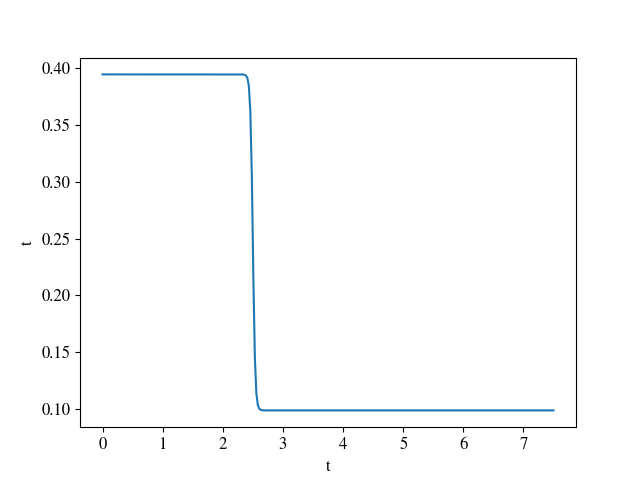

In [40]:
telescope = PotentialT( # We now use a PotentialT object
    unitvecs=[[s, 0], [0, s]],
    resolution=resolution,
    v0 = 0
)

T1 = 10
T2 = 20
w1 = 2*np.pi/T1
w2 = 2*np.pi/T2

t_final = T1/4 + T2/4

telescope.add_shape('trap', (telescope.x**2 + telescope.y**2) / 2) # A normalized harmonic trap is added to the shape context of the telescope 
telescope.step('step', ts = T1/4, sigma = T1/100, vi = w1**2, vf = w2**2) # A time-step function is added, controling the switch between trapping frequencies

telescope.add_term('step * trap')

telescope.plot_timefunction('step', tmin = 0, tmax = t_final, n_t=300)
plt.show()

In [41]:
t_samples = create_parameter('t', np.linspace(t_init, t_final, 99)) # We are going to save 99 time points

bar = SSFM(
    potential = telescope, psi0 = psi0, g = 0
)

psi = bar.solve(
    t_init, t_final, t_samples, parallelize=True, n_cores=6
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   11.4s remaining:   11.4s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   11.9s finished


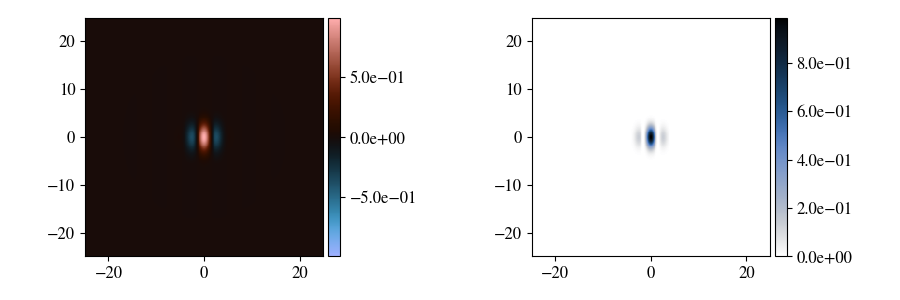

In [42]:
plot_eigenvector(
    [[psi.real, abs(psi)**2]], [[None]*2], [['real', 'amplitude']]
)
plt.show()

The final state $\psi(t = T_1 / 4 + T_2 / 4)$ is indeed a magnified version of the original state, with a further $\pi$-phaseshift added. Numerically-speaking, we have performed a very inefficient interpolation and cropping of our original states.

Now, we are going to a staggered honeycomb lattice with a large sublattice imbalance.

## Chiral supercurrents


In [43]:
kl = 2
a = 4*np.pi / 3**1.5 / kl
a1 = np.array([3 * a/2, -(3**0.5) * a/2])  # 1st lattice vector
a2 = np.array([3 * a/2, 3**0.5 * a/2])  # 2nd lattice vector

b1 = 3**0.5 * kl * np.array([1, -3**0.5])/2
b2 = 3**0.5 * kl * np.array([1, 3**0.5])/2

m = 1
hbar = 1
E_r = hbar**2 * kl**2 / 2 / m
# s0 = create_parameter('s0', np.linspace(3,10,3))
delta = 1
s1 = 7.83 - delta
s2 = 7.83 + delta

k1 = kl * np.array([-3**0.5 / 2 , 1/2])
k2 = kl * np.array([3**0.5 / 2 , 1/2])
k3 = kl * np.array([0,-1])

a1s = np.array([-1, 3**0.5])*2*np.pi/3/a 
a2s = np.array([1, 3**0.5])*2*np.pi/3/a
K = np.array([0, 4*np.pi/3**1.5/a])


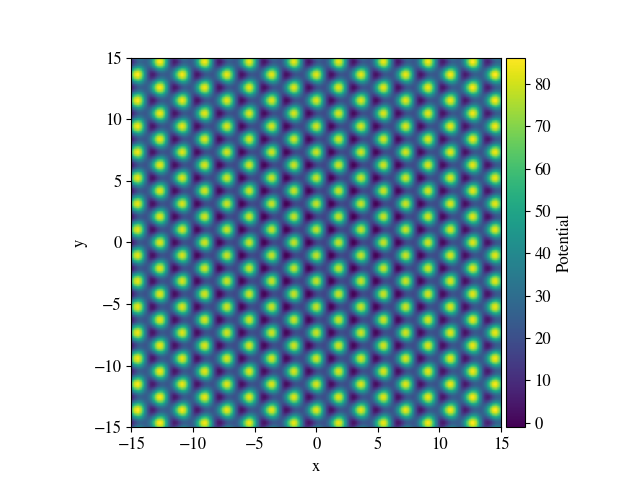

In [44]:


V1 = -s2*E_r
V2 = -s1*E_r

l = 30

honeycomb = Potential(
    unitvecs = [[l,0], [0,l]],
    resolution = (512, 512),
    v0 = 0,
)

### Lattice
dirs = [
    k1[0] * (honeycomb.x - a1[0]) + k1[1] * honeycomb.y,
    k2[0] * (honeycomb.x - a1[0]) + k2[1] * honeycomb.y,
    k3[0] * (honeycomb.x - a1[0]) + k3[1] * honeycomb.y,
]

tri_1 = 0
tri_2 = 0
for i in range(3):
    tri_1 += 2*np.cos((dirs[i-1]-dirs[i]) - 2*np.pi/3)/2
    tri_2 += 2*np.cos((dirs[i-1]-dirs[i]) + 2*np.pi/3)/2

honeycomb.set(tri_1 * V1 + tri_2 * V2) # We are going to re-use the initial potential later

### Large harmonic trap
trap = (honeycomb.x**2 + honeycomb.y**2) * 0.2**2 / 2
honeycomb.add(
    trap
)
honeycomb.add(- V1 - V2)

%matplotlib widget
honeycomb.plot()
plt.show()


In [45]:
from BECs.groundstate import GroundStateSSFM

g = 1

grd = GroundStateSSFM(
    honeycomb, g
)

energs, psi0 = grd.solve(
    population=100
)

Computing the ground states


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

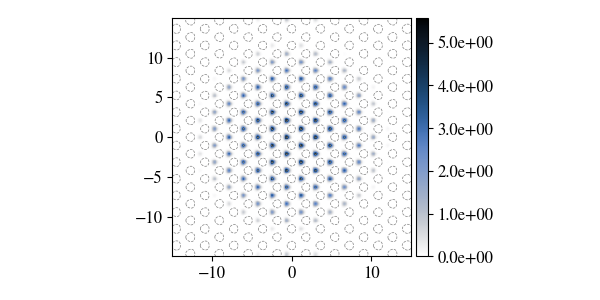

In [ ]:
from bloch_schrodinger.plotting import contour_tmpl

ctmp = contour_tmpl()
ctmp['fkwargs']['levels'] = 1

plot_eigenvector(
    [[abs(psi0)**2]], [[honeycomb]], [[('amplitude', ctmp)]]
)
plt.show()

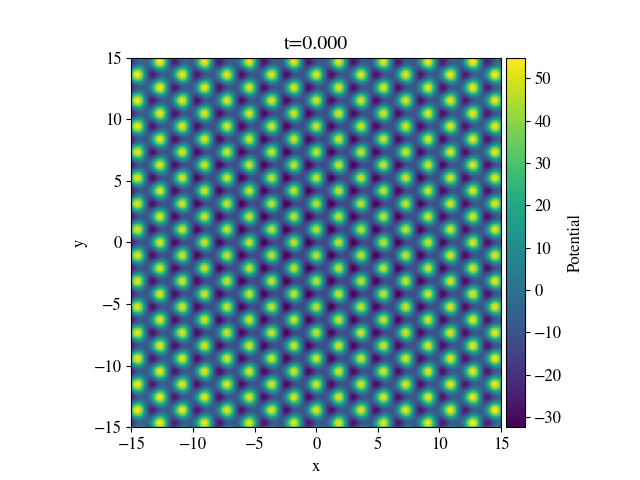

In [ ]:
%reload_ext autoreload
%autoreload 2

elevator:PotentialT = PotentialT.fromPotential(honeycomb)
elevator.set(trap)

t_i = 0
t_f = 20

t_sweep = 5
d_sweep = 3

elevator.add_shape('tri_1', tri_1)
elevator.add_shape('tri_2', tri_2)

elevator.step('sweep_1', t_sweep, d_sweep, V1, V2)
elevator.step('sweep_2', t_sweep, d_sweep, V2, V1)

elevator.add_term('tri_1 * sweep_1')
elevator.add_term('tri_2 * sweep_2')

elevator.plot_t(t_i,t_f, 300)
plt.show()


In [ ]:
foo = SSFM(
    elevator, psi0, g
)

t_samples = create_parameter('t', np.linspace(t_i, t_f, 100))

def fc(t):
    steep = 5/(0.1 + 1e-10)
    return 0 + (-0.003) * (1 / (1 + np.exp(-steep * (t - t_sweep+1))))

# foo.imaginary_time(fc)

psi = foo.solve(t_i, t_f, t_samples, verbose=True)

Propagating the initial states. 1 iterations to perform


100%|█████████▉| 19.985/20, 22.64s/it, [07:32 < 00:00]  


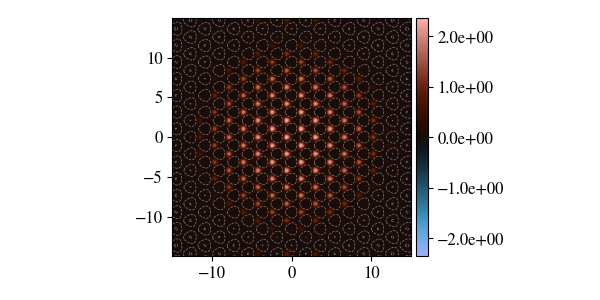

In [ ]:
plot_eigenvector(
    [[psi.real]], [[elevator.to_potential(t_samples)]], [[('real', ctmp)]]
)
plt.show()